# DG advection from sampled noisy data and SIAC postprocessing

In this notebook, we modify the previous noisy-data experiment by introducing the noise on a fixed set of sampled data points before projecting onto the DG space. The goal is to study a setting closer to data-driven approximation, where the initial condition is not available as an exact callable function during projection, but only through discrete samples.

We start from a sampled initial condition on a one-dimensional grid,

$$
    \{(x_i, f_i)\}_{i=1}^{N},
$$

where the sampled values are given by

$$
    f_i = f(x_i) + \varepsilon \eta_i.
$$

Here $f$ is the exact initial condition, $\eta_i$ are independent standard Gaussian random variables,

$$
    \eta_i \sim \mathcal{N}(0,1),
$$

and the noise amplitude is scaled as

$$
    \varepsilon = C h^q.
$$

The parameter $h$ denotes the DG mesh size, $C$ is a fixed constant, and $q$ controls how quickly the noise amplitude decreases under mesh refinement. As before, we consider choices such as

$$
    q \in \{p+1,\, r+1,\, r+2\},
$$

where $p$ is the DG polynomial degree and $r$ is the enforced polynomial reproduction degree of the SIAC kernel.

Unlike the previous notebook, the noisy data are not evaluated directly at the projection quadrature points. Instead, the sampled grid is first augmented by inserting the DG mesh edges. The corresponding values at inserted mesh edges are obtained by linear interpolation. On each DG element, the sampled data are then projected using a composite trapezoidal rule in reference coordinates.

Thus, the initial DG approximation is constructed as a discrete-data projection,

$$
    u_h^0 \approx \Pi_h f_{\mathrm{sampled}},
$$

where $f_{\mathrm{sampled}}$ denotes the noisy sampled representation of the initial condition. The resulting DG solution is evolved with the advection solver and finally postprocessed using SIAC filtering.

This setup allows us to compare the effect of SIAC postprocessing when the initial error comes not only from DG projection and time evolution, but also from finite-resolution noisy sampled data.

In [38]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.mesh import build_uniform_mesh
from src.projection import l2_project_sampled_mesh_trapezoid
from src.dg_solver import dg_rhs_advection
from src.time_integrators import forward_euler_step, rk4_step, time_integrator
from src.cfl import estimate_dt_advection, choose_time_step
from src.evaluation import evaluate_dg_solution
from src.metrics import linf_error, l2_error_dg, relative_l2_error_dg, relative_l2_error_from_grid
from src.siac import apply_siac_to_modal_dg_1d

In [40]:
# Wave speed
a = 2

# Total Time
T = 2

# time stepping method: rk4 or euler (forward_euler)
time_method = "rk4"

# Define the domain
xmin, xmax = -1, 1
domain = (-1, 1)

# DG setup
p = 2
order = p + 1
K = 32

# Postprocessor (SIAC) setup
moments = 2*p   # Must be even
BSorder = p+1

# Exact function (periodic)
def exact_func(x):
    return np.sin(2*np.pi*x)

# create mesh
mesh = build_uniform_mesh(K=K, domain=domain)

# Build initial sampled noisy data

# Test with noise q = p + 1, r + 1 or r + 2
q = p + 1

# Sample grid
num_samples = 4000
grid = np.linspace(xmin, xmax, num_samples)

# Exact sampled data
u_exact_data = exact_func(grid)

# Noise amplitude
h = (xmax - xmin) / K
C = 1.0
epsilon = C * h**q

# Sample independent standard Gaussian noise
rng = np.random.default_rng(seed=42)
eta = rng.normal(loc=0.0, scale=1.0, size=grid.shape)

# Noisy sampled data
u_data = u_exact_data + epsilon * eta

dg = l2_project_sampled_mesh_trapezoid(
    x_data=grid,
    u_data=u_data,
    p=p,
    mesh=mesh,
)

dg["u_exact_sample"] = u_exact_data
dg["noise_sample"] = eta
dg["epsilon"] = epsilon
dg["q"] = q
dg["C"] = C

# Define RHS wrapper
def rhs(u, t):
    return dg_rhs_advection(
        coeffs=u, 
        mesh=mesh, 
        p=p, 
        a=a
    )

# choose time stepping from CFL conditions
dt_est = estimate_dt_advection(mesh=mesh, p=p, a=a, method=time_method, safety=0.9)
dt, num_steps = choose_time_step(T=T, dt_est=dt_est)

print(f"dt = {dt}")
print(f"num_steps = {num_steps}")



dt = 0.0056179775280898875
num_steps = 356


In [41]:
time_tol = 1e-12

u = dg["coeffs"].copy()
t = 0.0

for n in range(num_steps):
    dt_step = min(dt, T - t)

    if dt_step <= time_tol:
        break

    u = time_integrator(rhs, u, t, dt_step, method=time_method)
    t += dt_step

# Snap final time to T if only roundoff remains
if abs(T - t) <= time_tol:
    t = T
else:
    raise RuntimeError(f"Time stepping stopped at t={t}, not T={T}.")

dg_final = dg.copy()
dg_final["coeffs"] = u
dg_final["t"] = t

In [42]:
# number of evaluation points per element/cell
ppe = 20

eval_grid, U_dg = evaluate_dg_solution(dg_final, points_per_cell=ppe)

t_final = dg_final["t"]

def exact_solution(x, t):
    return exact_func(x - a*t)

U_exact = exact_solution(eval_grid, t_final)

# pointwise Linf using plotting/evaluation grid
err_linf = linf_error(U_dg, U_exact)

# quadrature-based L2 errors
err_l2 = l2_error_dg(dg_final, exact_solution, t=dg_final["t"])
err_l2_rel = relative_l2_error_dg(dg_final, exact_solution, t=dg_final["t"])

print(f"Linf error       = {err_linf:.3e}")
print(f"L2 error         = {err_l2:.3e}")
print(f"Relative L2 error = {err_l2_rel:.3e}")

Linf error       = 1.025e-03
L2 error         = 2.978e-04
Relative L2 error = 2.978e-04


In [43]:
# Postprocessor

U_star = apply_siac_to_modal_dg_1d(dg=dg_final, moments=moments, BSorder=BSorder, points_per_cell=ppe)

In [44]:
# slice all to interior for valid comparison
halfker = int(np.ceil((moments + BSorder) / 2))

# Only valid in interior
start = halfker * ppe
stop = (K - halfker) * ppe

eval_grid_int = eval_grid[start:stop]
U_dg_int = U_dg[start:stop]
U_exact_int = U_exact[start:stop]
U_star_int = U_star[start:stop]


# pointwise Linf using plotting/evaluation grid
err_linf_U = linf_error(U_dg_int, U_exact_int)
err_linf_Ustar = linf_error(U_star_int, U_exact_int)

print(f"Linf error u       = {err_linf_U:.3e}")
print(f"Linf error u_star  = {err_linf_Ustar:.3e}")

Linf error u       = 1.025e-03
Linf error u_star  = 6.786e-05


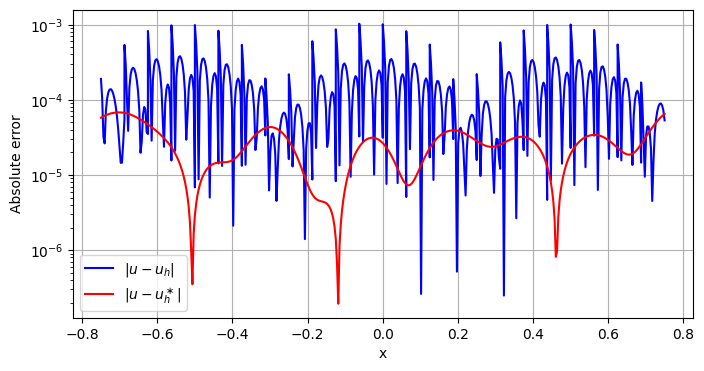

In [45]:
# pointwise error
abs_error_u = np.abs(U_dg_int - U_exact_int)
abs_error_ustar = np.abs(U_star_int - U_exact_int)


plt.figure(figsize=(8, 4))
plt.semilogy(eval_grid_int, abs_error_u, "b", label=r"$|u-u_h|$")
plt.semilogy(eval_grid_int, abs_error_ustar, "r", label=r"$|u-u_h^\ast|$")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.legend()
plt.grid(True)
plt.show()